In [6]:
%cd /content/drive/MyDrive/rice_resnet/

/content/drive/MyDrive/rice_resnet


In [7]:
!rm -rf data/rice_disease/.ipynb_checkpoints

In [8]:
# ── 1. IMPORTS & STYLE ───────────────────────────────────────────────────────
import os, copy, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

PALETTE  = ["#E74C3C", "#2980B9", "#27AE60"]
BG_COLOR = "#FFFFFF"; PLOT_BG = "#FAFAFC"; GRID_CLR = "#E0E4E8"
TEXT_CLR = "#2C3E50"; ACCENT  = "#F39C12"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor": PLOT_BG,
    "axes.edgecolor": "#BDC3C7", "axes.labelcolor": TEXT_CLR,
    "axes.titlecolor": TEXT_CLR, "axes.titleweight": "bold",
    "axes.titlesize": 14, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TEXT_CLR, "ytick.color": TEXT_CLR, "text.color": TEXT_CLR,
    "grid.color": GRID_CLR, "grid.linestyle": "--", "grid.alpha": 0.8,
    "legend.facecolor": BG_COLOR, "legend.edgecolor": "#BDC3C7",
    "font.family": "sans-serif", "font.size": 11,
})


In [9]:
# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DATA_DIR   = "data/rice_disease"
OUTPUT_DIR = "outputs_effnet_kfold"
CKPT_DIR   = "checkpoints_effnet_kfold"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

IMG_SIZE       = 224
BATCH_SIZE     = 16
EPOCHS         = 30
LR             = 1e-4
LR_HEAD        = 1e-3
WEIGHT_DECAY   = 1e-4
NUM_WORKERS    = 2
UNFREEZE_EPOCH = 5
N_FOLDS        = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
GPU    : Tesla T4


Classes (3) : ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Total images    : 120


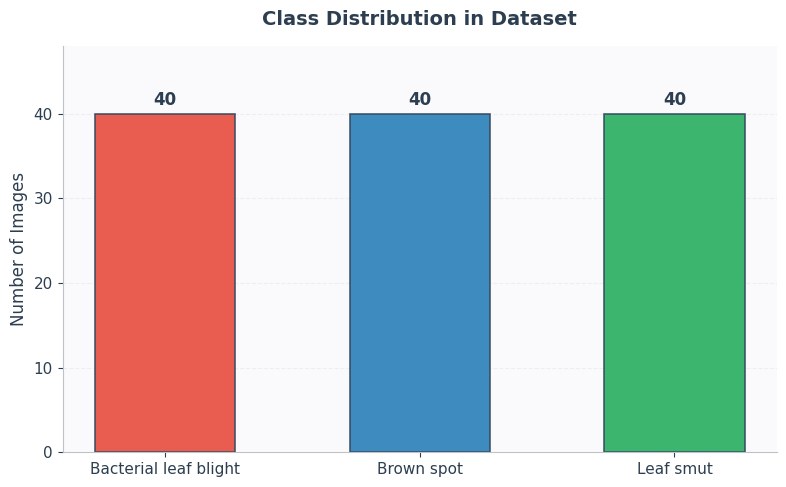

In [10]:
# ── 3. TRANSFORMS & DATASET ──────────────────────────────────────────────────
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 64, IMG_SIZE + 64)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(root=DATA_DIR)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
all_labels   = [label for _, label in full_dataset.samples]
all_indices  = list(range(len(full_dataset)))
print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Total images    : {len(full_dataset)}")

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

# Class distribution plot
def plot_class_distribution():
    counts = [all_labels.count(i) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(CLASS_NAMES, counts, color=PALETTE, width=0.55, edgecolor="#34495E", linewidth=1.2, alpha=0.9)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(count),
                ha="center", va="bottom", fontsize=12, fontweight="bold", color=TEXT_CLR)
    ax.set_title("Class Distribution in Dataset", pad=15)
    ax.set_ylabel("Number of Images", fontsize=12)
    ax.set_ylim(0, max(counts)*1.2); ax.grid(axis="y", alpha=0.5); ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"01_class_distribution.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_class_distribution()


In [11]:
# ── 4. MODEL ──────────────────────────────────────────────────────────────────
def build_efficientnet_b1(num_classes):
    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    # Freeze backbone initially
    for param in model.features.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return model

def get_optimizer(model, head_lr=LR_HEAD, backbone_lr=LR):
    head_params     = list(model.classifier.parameters())
    backbone_params = [p for p in model.parameters() if not any(p is hp for hp in head_params)]
    return optim.Adam([
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params,     "lr": head_lr},
    ], weight_decay=WEIGHT_DECAY)


In [12]:
# ── 5. TRAINING FUNCTIONS ────────────────────────────────────────────────────
criterion_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False, desc="Training")
    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        loop.set_postfix(loss=loss.item())
    return running_loss / total, 100.0 * correct / total

def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    loop = tqdm(loader, leave=False, desc="Validating")
    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (running_loss/total, 100.0*correct/total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


In [13]:
# ── 6. 5-FOLD TRAINING LOOP ──────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_histories = []
oof_preds, oof_labels, oof_probs = [], [], []

print("\n── EfficientNet-B1 | 5-Fold Cross Validation ──────────────────────")

for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels), start=1):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold}/{N_FOLDS} | Train: {len(train_idx)} | Val: {len(val_idx)}")
    print(f"{'='*60}")

    train_ds_fold = TransformSubset(Subset(full_dataset, train_idx), train_transforms)
    val_ds_fold   = TransformSubset(Subset(full_dataset, val_idx),   val_transforms)
    train_loader  = DataLoader(train_ds_fold, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader    = DataLoader(val_ds_fold,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model      = build_efficientnet_b1(NUM_CLASSES).to(DEVICE)
    optimizer  = get_optimizer(model)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    history    = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"lr":[]}
    best_val_acc   = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    CHECKPOINT     = os.path.join(CKPT_DIR, f"best_effnet_fold{fold}.pth")

    for epoch in range(1, EPOCHS + 1):
        if epoch == UNFREEZE_EPOCH + 1:
            print(f"\n[Epoch {epoch}] Unfreezing backbone for end-to-end fine-tuning ...")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = get_optimizer(model, head_lr=LR_HEAD, backbone_lr=LR)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - UNFREEZE_EPOCH, eta_min=1e-7)

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader)
        scheduler.step()

        current_lr = optimizer.param_groups[-1]["lr"]
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        tag = ""
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, CHECKPOINT)
            tag = "  ← Best Saved"

        print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.2e}{tag}")

    print(f"\nFold {fold} Best Val Accuracy : {best_val_acc:.2f}%")

    # ── Per-fold classification report (like our modular approach) ────────────
    model.load_state_dict(best_model_wts)
    _, _, fold_preds, fold_labels, fold_probs = evaluate(model, val_loader)

    fold_acc  = 100.0 * accuracy_score(fold_labels, fold_preds)
    fold_prec = precision_score(fold_labels, fold_preds, average='macro', zero_division=0)
    fold_rec  = recall_score(fold_labels, fold_preds, average='macro', zero_division=0)
    fold_f1   = f1_score(fold_labels, fold_preds, average='macro', zero_division=0)

    print(f"\n── Fold {fold} Metrics ──────────────────────────")
    print(f"  Accuracy : {fold_acc:.2f}%")
    print(f"  Precision: {fold_prec:.4f}")
    print(f"  Recall   : {fold_rec:.4f}")
    print(f"  F1 Score : {fold_f1:.4f}")
    print("\nPer-Class Report:")
    print(classification_report(fold_labels, fold_preds, target_names=CLASS_NAMES, zero_division=0))

    fold_histories.append(history)
    oof_preds.extend(fold_preds)
    oof_labels.extend(fold_labels)
    oof_probs.extend(fold_probs)



── EfficientNet-B1 | 5-Fold Cross Validation ──────────────────────

  FOLD 1/5 | Train: 96 | Val: 24
Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 127MB/s]


Training:   0%|          | 0/6 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [01/30] | Train Loss: 1.0591 Acc: 43.75% | Val Loss: 0.9795 Acc: 62.50% | LR: 9.97e-04  ← Best Saved


...

Training:   0%|          | 0/6 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [30/30] | Train Loss: 0.3766 Acc: 98.96% | Val Loss: 0.4921 Acc: 91.67% | LR: 1.00e-07

Fold 5 Best Val Accuracy : 91.67%


Validating:   0%|          | 0/2 [00:00<?, ?it/s]


── Fold 5 Metrics ──────────────────────────
  Accuracy : 91.67%
  Precision: 0.9333
  Recall   : 0.9167
  F1 Score : 0.9153

Per-Class Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.80      1.00      0.89         8
           Brown spot       1.00      0.75      0.86         8
            Leaf smut       1.00      1.00      1.00         8

             accuracy                           0.92        24
            macro avg       0.93      0.92      0.92        24
         weighted avg       0.93      0.92      0.92        24




  CROSS-VALIDATION AGGREGATED RESULTS (OUT-OF-FOLD)
  Overall Accuracy  : 90.00%
  Overall Precision : 0.9003
  Overall Recall    : 0.9000
  Overall F1 Score  : 0.8993

Per-class OOF Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.91      0.97      0.94        40
           Brown spot       0.88      0.88      0.88        40
            Leaf smut       0.92      0.85      0.88        40

             accuracy                           0.90       120
            macro avg       0.90      0.90      0.90       120
         weighted avg       0.90      0.90      0.90       120



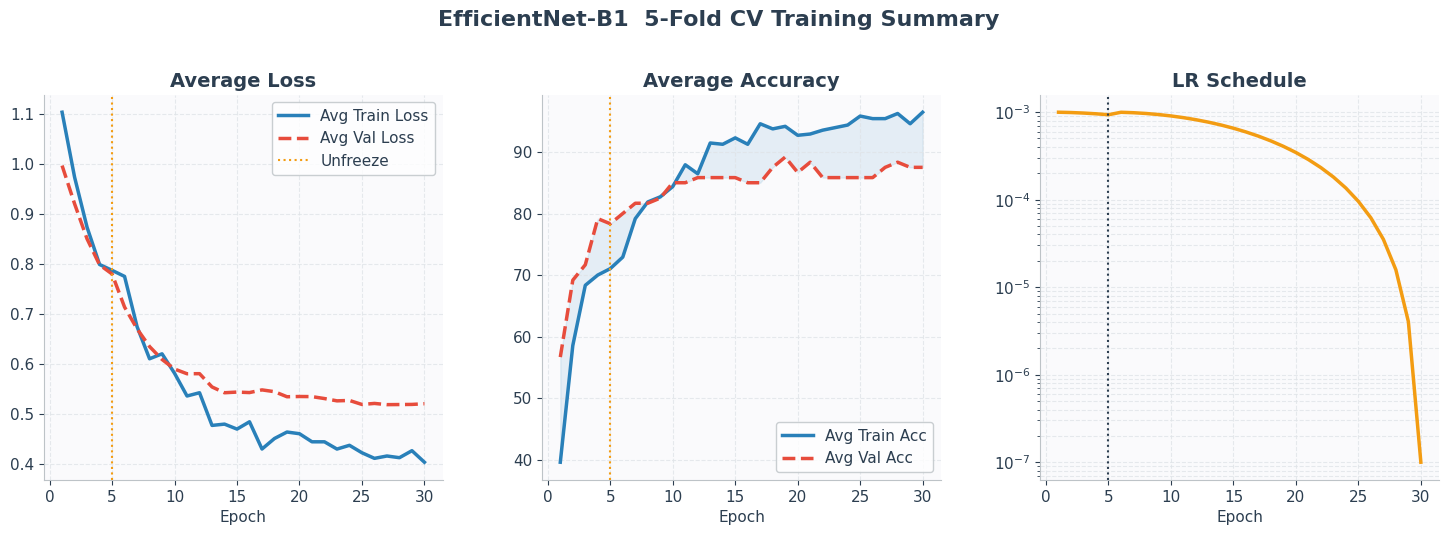

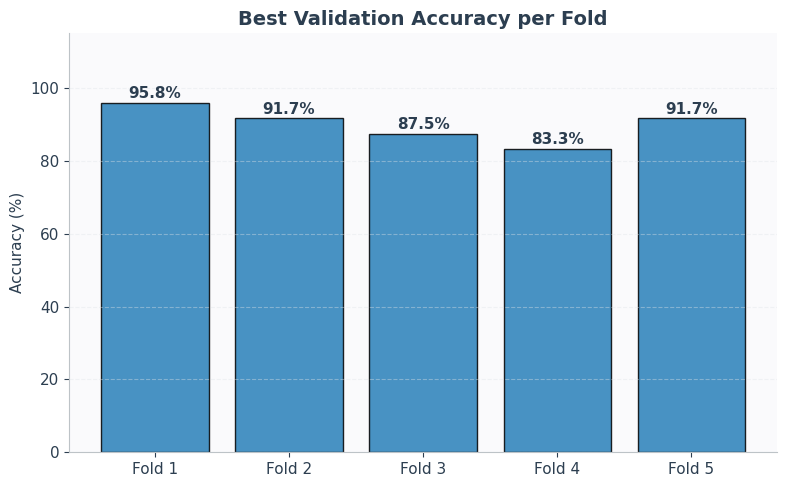

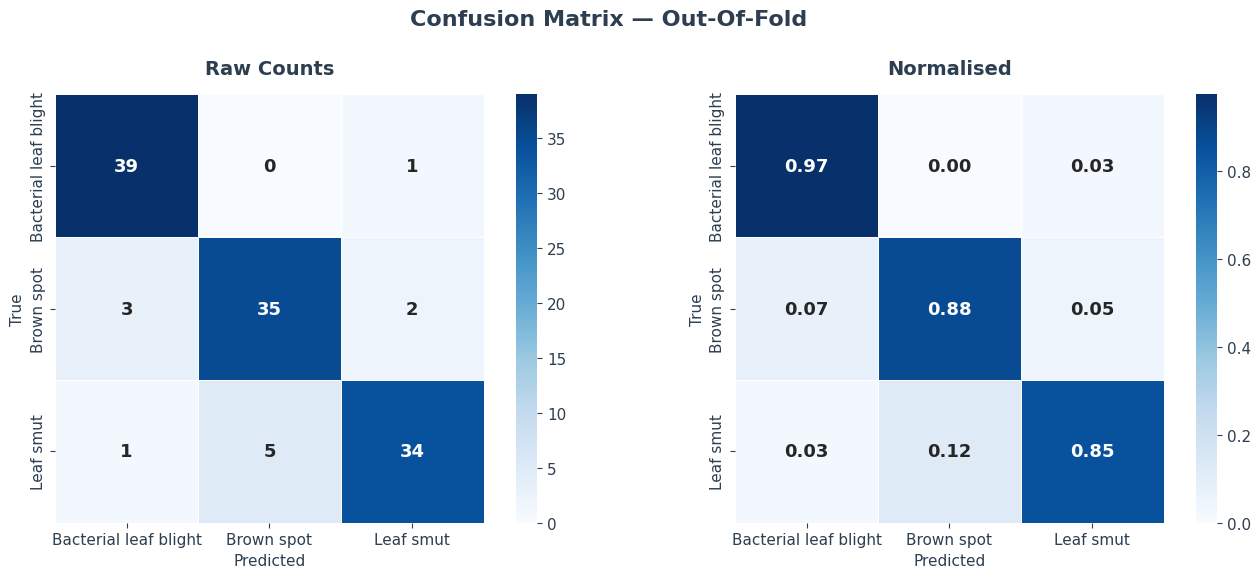

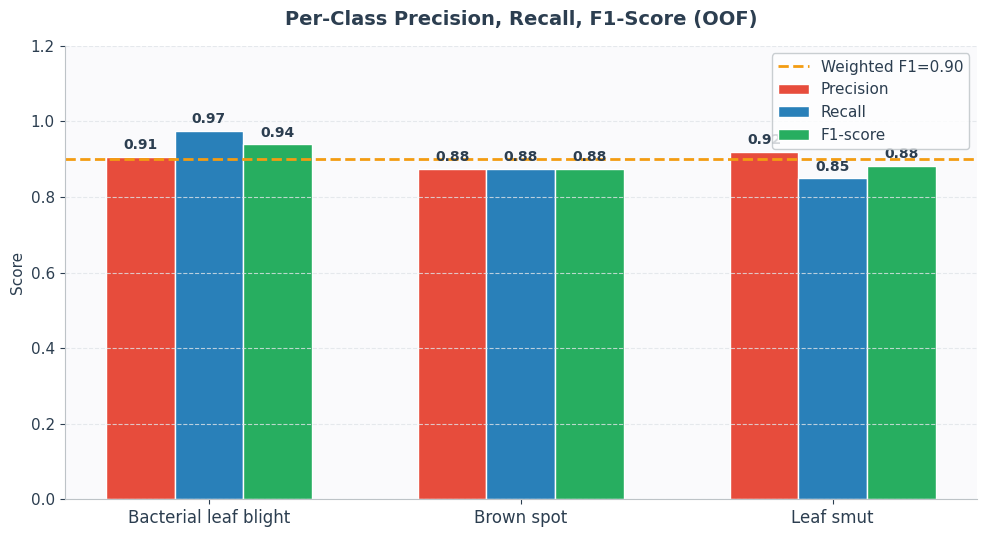

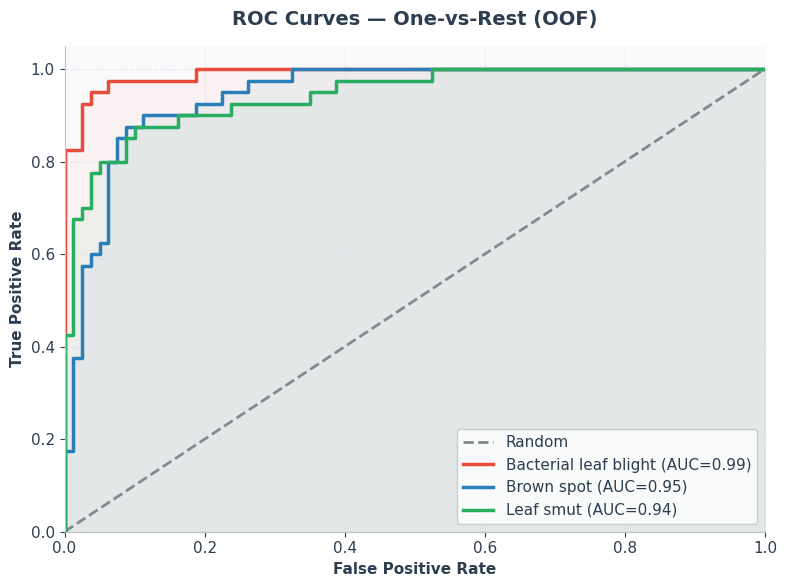

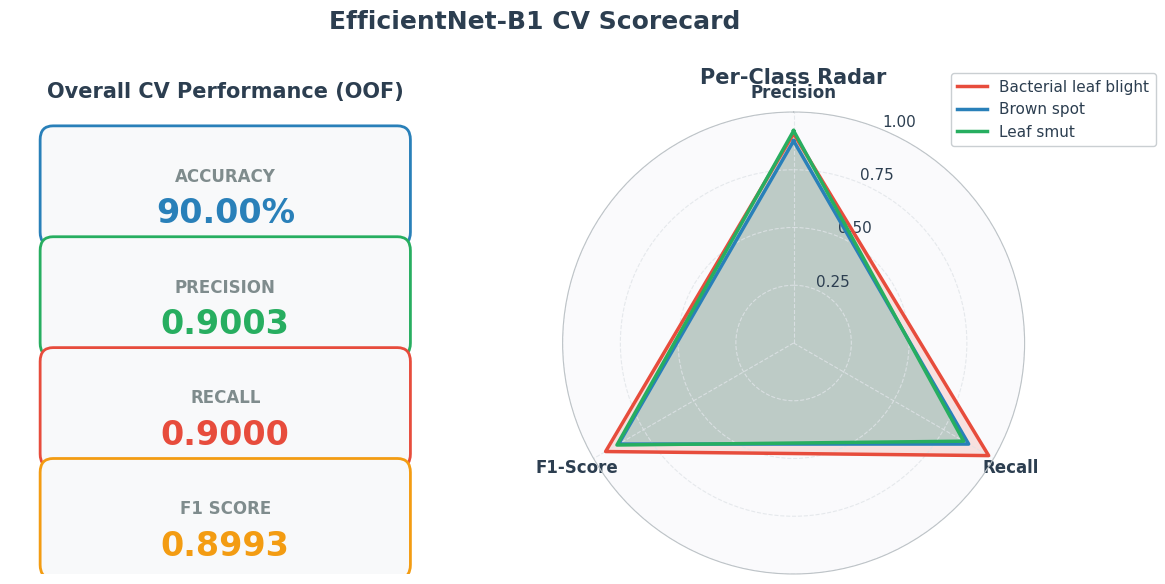


  All outputs saved to: outputs_effnet_kfold


In [14]:
# ── 7. AGGREGATED OOF EVALUATION ─────────────────────────────────────────────
oof_preds  = np.array(oof_preds)
oof_labels = np.array(oof_labels)
oof_probs  = np.array(oof_probs)

acc       = 100.0 * (oof_preds == oof_labels).mean()
precision = precision_score(oof_labels, oof_preds, average="weighted", zero_division=0)
recall    = recall_score(   oof_labels, oof_preds, average="weighted", zero_division=0)
f1        = f1_score(       oof_labels, oof_preds, average="weighted", zero_division=0)

print("\n" + "="*60)
print("  CROSS-VALIDATION AGGREGATED RESULTS (OUT-OF-FOLD)")
print("="*60)
print(f"  Overall Accuracy  : {acc:.2f}%")
print(f"  Overall Precision : {precision:.4f}")
print(f"  Overall Recall    : {recall:.4f}")
print(f"  Overall F1 Score  : {f1:.4f}")
print("\nPer-class OOF Report:")
print(classification_report(oof_labels, oof_preds, target_names=CLASS_NAMES, zero_division=0))

# Average training curves
def plot_avg_curves(histories):
    epochs_range = range(1, EPOCHS + 1)
    avg_tl = np.mean([h["train_loss"] for h in histories], axis=0)
    avg_vl = np.mean([h["val_loss"]   for h in histories], axis=0)
    avg_ta = np.mean([h["train_acc"]  for h in histories], axis=0)
    avg_va = np.mean([h["val_acc"]    for h in histories], axis=0)
    lr_h   = histories[0]["lr"]

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(epochs_range, avg_tl, color=PALETTE[1], lw=2.5, label="Avg Train Loss")
    ax0.plot(epochs_range, avg_vl, color=PALETTE[0], lw=2.5, linestyle="--", label="Avg Val Loss")
    ax0.axvline(UNFREEZE_EPOCH, color=ACCENT, lw=1.5, linestyle=":", label="Unfreeze")
    ax0.set_title("Average Loss"); ax0.set_xlabel("Epoch"); ax0.legend(); ax0.grid(True)

    ax1 = fig.add_subplot(gs[1])
    ax1.plot(epochs_range, avg_ta, color=PALETTE[1], lw=2.5, label="Avg Train Acc")
    ax1.plot(epochs_range, avg_va, color=PALETTE[0], lw=2.5, linestyle="--", label="Avg Val Acc")
    ax1.axvline(UNFREEZE_EPOCH, color=ACCENT, lw=1.5, linestyle=":")
    ax1.fill_between(epochs_range, avg_ta, avg_va, alpha=0.1, color=PALETTE[1])
    ax1.set_title("Average Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

    ax2 = fig.add_subplot(gs[2])
    ax2.plot(epochs_range, lr_h, color=ACCENT, lw=2.5)
    ax2.axvline(UNFREEZE_EPOCH, color=TEXT_CLR, lw=1.5, linestyle=":")
    ax2.set_title("LR Schedule"); ax2.set_xlabel("Epoch"); ax2.set_yscale("log"); ax2.grid(True, which="both")

    fig.suptitle("EfficientNet-B1  5-Fold CV Training Summary", fontsize=16, fontweight="bold", y=1.05)
    fig.savefig(os.path.join(OUTPUT_DIR,"02_avg_training_curves.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_avg_curves(fold_histories)

# Fold bar chart
def plot_fold_bar():
    fold_accs = [max(h["val_acc"]) for h in fold_histories]
    folds = [f"Fold {i+1}" for i in range(N_FOLDS)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(folds, fold_accs, color=PALETTE[1], edgecolor="black", alpha=0.85)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, yval+0.5, f"{yval:.1f}%",
                ha="center", va="bottom", fontweight="bold")
    ax.set_title("Best Validation Accuracy per Fold"); ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 115); ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"03_fold_accuracy_bar.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_fold_bar()

# Confusion matrix
def plot_confusion_matrix(labels, preds, class_names):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle("Confusion Matrix — Out-Of-Fold", fontsize=16, fontweight="bold", y=1.02)
    for ax, data, title, fmt in zip(axes, [cm, cm_norm], ["Raw Counts","Normalised"], ["d",".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5, annot_kws={"size":13,"weight":"bold"}, square=True)
        ax.set_title(title, pad=15)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"04_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_confusion_matrix(oof_labels, oof_preds, CLASS_NAMES)

# Per-class metrics bar
def plot_per_class_metrics(labels, preds, class_names):
    report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    metrics   = ["precision","recall","f1-score"]
    x         = np.arange(len(class_names)); bar_width = 0.22
    fig, ax   = plt.subplots(figsize=(10, 5.5))
    for i, (metric, color) in enumerate(zip(metrics, PALETTE)):
        vals = [report[cls][metric] for cls in class_names]
        bars = ax.bar(x + i*bar_width, vals, bar_width, label=metric.capitalize(), color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}",
                    ha="center", fontsize=10, fontweight="bold", color=TEXT_CLR)
    ax.set_xticks(x + bar_width); ax.set_xticklabels(class_names, fontsize=12)
    ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
    ax.set_title("Per-Class Precision, Recall, F1-Score (OOF)", pad=15)
    overall_f1 = report["weighted avg"]["f1-score"]
    ax.axhline(overall_f1, color=ACCENT, lw=2, linestyle="--", label=f"Weighted F1={overall_f1:.2f}")
    ax.legend(loc="upper right"); ax.grid(axis="y")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"05_per_class_metrics.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_per_class_metrics(oof_labels, oof_preds, CLASS_NAMES)

# ROC curves
def plot_roc_curves(labels, probs, class_names):
    y_bin = label_binarize(labels, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0,1],[0,1], color="#7F8C8D", lw=2, linestyle="--", label="Random")
    for i, (cls, color) in enumerate(zip(class_names, PALETTE)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC={roc_auc:.2f})")
        ax.fill_between(fpr, tpr, alpha=0.05, color=color)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate",  fontweight="bold")
    ax.set_title("ROC Curves — One-vs-Rest (OOF)", pad=15)
    ax.legend(loc="lower right"); ax.grid(True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"06_roc_curves.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_roc_curves(oof_labels, oof_probs, CLASS_NAMES)

# Scorecard
def plot_scorecard(acc, precision, recall, f1, class_names, labels, preds):
    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.1, width_ratios=[1,1.4])
    ax_left = fig.add_subplot(gs[0]); ax_left.axis("off")
    metrics_data = [("Accuracy",f"{acc:.2f}%",PALETTE[1]),("Precision",f"{precision:.4f}",PALETTE[2]),
                    ("Recall",f"{recall:.4f}",PALETTE[0]),("F1 Score",f"{f1:.4f}",ACCENT)]
    for idx, (name, value, color) in enumerate(metrics_data):
        y = 0.82 - idx*0.24
        ax_left.add_patch(mpatches.FancyBboxPatch((0.1,y-0.08),0.8,0.20,boxstyle="round,pad=0.03",
                          facecolor="#F8F9FA",edgecolor=color,linewidth=2,transform=ax_left.transAxes))
        ax_left.text(0.5,y+0.04,name.upper(),ha="center",va="center",fontsize=12,fontweight="bold",
                     color="#7F8C8D",transform=ax_left.transAxes)
        ax_left.text(0.5,y-0.04,value,ha="center",va="center",fontsize=24,fontweight="bold",
                     color=color,transform=ax_left.transAxes)
    ax_left.set_title("Overall CV Performance (OOF)", fontsize=15, pad=10)

    report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    cats   = ["Precision","Recall","F1-Score"]; N = len(cats)
    angles = [n/float(N)*2*np.pi for n in range(N)]; angles += angles[:1]
    ax_r   = fig.add_subplot(gs[1], polar=True)
    ax_r.set_facecolor(PLOT_BG); ax_r.set_theta_offset(np.pi/2); ax_r.set_theta_direction(-1)
    ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(cats, fontsize=12, fontweight="bold")
    ax_r.set_ylim(0,1); ax_r.set_yticks([0.25,0.5,0.75,1.0])
    for cls, color in zip(class_names, PALETTE):
        vals  = [report[cls]["precision"],report[cls]["recall"],report[cls]["f1-score"]]; vals += vals[:1]
        ax_r.plot(angles, vals, color=color, lw=2.5, label=cls)
        ax_r.fill(angles, vals, color=color, alpha=0.15)
    ax_r.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
    ax_r.set_title("Per-Class Radar", fontsize=15, pad=20)
    fig.suptitle("EfficientNet-B1 CV Scorecard", fontsize=18, fontweight="bold", y=1.05)
    fig.savefig(os.path.join(OUTPUT_DIR,"07_scorecard.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_scorecard(acc, precision, recall, f1, CLASS_NAMES, oof_labels, oof_preds)

print("\n" + "="*60)
print("  All outputs saved to:", OUTPUT_DIR)
print("="*60)


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls


drive  sample_data


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks"

In [2]:
import json

with open('your_notebook.ipynb', 'r') as f:
    nb = json.load(f)

# Remove problematic widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open('fixed_notebook.ipynb', 'w') as f:
    json.dump(nb, f)

print("Fixed notebook saved as fixed_notebook.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'resnet50.ipynb'